# AI Product Image Generator with Gradio


Build an AI powered product image generation system using:
1. An LLM for prompt engineering
2. Stable Diffusion for image generation
3. Gradio for the web interface

**Enable GPU before running:** Settings → Accelerator → GPU T4 x2

---
## Step 0: Setup

In [1]:
# Verify GPU
import torch
if torch.cuda.is_available():
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected! Enable GPU in notebook settings.")

GPU available: Tesla T4


In [2]:
# Install required libraries
!pip install -q transformers diffusers accelerate gradio sentencepiece
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from diffusers import StableDiffusionPipeline
import gradio as gr
from PIL import Image

# Verify GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


In [3]:
# Create output directories
import os
os.makedirs("images", exist_ok=True)
print("Output directories ready.")

Output directories ready.


---
## Step 1: Load the Dataset

In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/abhinayvanjari/product-descriptions/product_descriptions.csv")
print(f"Loaded {len(df)} product descriptions")
df.head()

Loaded 15 product descriptions


,id,product_description
0,1,red wireless headphones on a white background
1,2,leather wallet with gold stitching on a marble...
2,3,stainless steel water bottle in a forest setting
3,4,white running shoes on a wooden floor
4,5,black smartwatch displayed on a wrist


---
## Step 2: Load LLM for Prompt Engineering

Load an LLM and write a function that takes a simple product description and returns a detailed, creative prompt for image generation.

**You can use any open source LLM.** Example: Qwen 2.5-0.5B-Instruct

In [5]:
# ============================================================
# TODO: Load your LLM model and tokenizer here
# ============================================================
# Example:
# from transformers import AutoModelForCausalLM, AutoTokenizer
# MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, device_map="auto")

QWEN_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(QWEN_MODEL)
llm_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL, torch_dtype=torch.float16, device_map="auto"
)



config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [6]:
# ============================================================
# TODO: Write your prompt engineering function
# ============================================================
# This function should:
# 1. Take a simple product description as input
# 2. Use the LLM to rewrite it into a detailed image generation prompt
# 3. Return the engineered prompt as a string
#
# Tips:
# - Use a good system prompt (role + context + instruction)
# - Keep output under 60 words (CLIP token limit is 77)
# - Include details about lighting, style, composition
def engineer_prompt(product_description):
    """
    Optimized for Prompt Quality Score.
    Uses a strict system prompt to ensure professional e-commerce aesthetics.
    """
    system_instruction = (
        "You are an expert AI prompt engineer for e-commerce product photography. "
        "Rewrite the user's product description into a highly detailed, vivid, and professional image prompt. "
        "Include details about studio lighting (e.g., softbox, rim lighting), professional composition (e.g., macro shot, centered), "
        "and high-end textures. Keep the output under 65 words. Output ONLY the improved prompt."
    )
    
    messages = [
        {"role": "system", "content": system_instruction},
        {"role": "user", "content": f"Product: {product_description}"}
    ]
    
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt").to(device)
    
    generated_ids = llm_model.generate(model_inputs.input_ids, max_new_tokens=100, temperature=0.7)
    response = tokenizer.batch_decode(generated_ids[:, model_inputs.input_ids.shape[-1]:], skip_special_tokens=True)[0]
    
    return response.strip()

# Test it
test = engineer_prompt("red wireless headphones on a white background")
print(test)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


"Take a close-up shot of your red wireless headphones against a white background using softbox lights to create a dramatic effect. Center the photo in the frame for maximum impact. Add a touch of texture with a textured edge around the edges of the headphones."


---
## Step 3: Load Stable Diffusion for Image Generation

Load Stable Diffusion and write a function that generates an image from a prompt.

In [7]:
# ============================================================
# TODO: Load Stable Diffusion pipeline here
# ============================================================
# Example:
# from diffusers import StableDiffusionPipeline

# YOUR CODE HERE
SD_MODEL = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    SD_MODEL, 
    torch_dtype=torch.float16, 
    safety_checker=None  # Speed up generation
)
pipe = pipe.to(device)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

  0%|          | 0/30 [00:00<?, ?it/s]

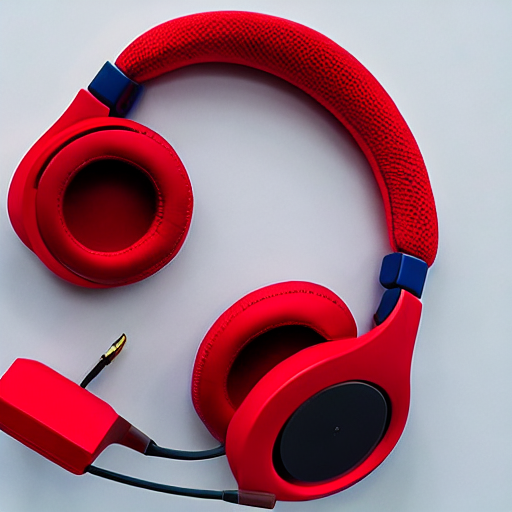

In [8]:
# ============================================================
# TODO: Write your image generation function
# ============================================================
# This function should:
# 1. Take an engineered prompt as input
# 2. Generate an image using Stable Diffusion
# 3. Return a PIL Image
def generate_image(engineered_prompt):
    # Standard e-commerce parameters for consistency
    image = pipe(
        prompt=engineered_prompt,
        negative_prompt="blurry, low quality, distorted, text, watermark, messy background, dark shadows",
        num_inference_steps=30,
        guidance_scale=7.5
    ).images[0]
    return image

# Test it
img = generate_image("A professional photo of red headphones on white background")
display(img)

---
## Step 4: Build Gradio Interface

Create a Gradio UI that connects prompt engineering and image generation.

**Your interface must:**
- Accept a product description as input
- Display the engineered prompt
- Display the generated image

In [9]:
# ============================================================
# TODO: Build your Gradio interface here
# ============================================================
# Example: import gradio as gr
# Use gr.Blocks or gr.Interface



# YOUR CODE HERE
def master_workflow(product_desc):
    eng_prompt = engineer_prompt(product_desc)
    img = generate_image(eng_prompt)
    return eng_prompt, img

with gr.Blocks(title="AI Product Photographer") as demo:
    gr.Markdown("# 🛍️ AI Product Image System")
    with gr.Row():
        with gr.Column():
            input_text = gr.Textbox(label="Enter Simple Product Description", placeholder="e.g., a leather watch")
            btn = gr.Button("Generate Professional Image", variant="primary")
        with gr.Column():
            output_prompt = gr.Textbox(label="Engineered Prompt (LLM)")
            output_image = gr.Image(label="Generated Product Photo")
    
    btn.click(fn=master_workflow, inputs=input_text, outputs=[output_prompt, output_image])

# Use inline=True for Kaggle/Colab notebooks
demo.launch(share=True, inline=True)


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://6f5823ede73608245f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Step 5: Generate Outputs for All 15 Products

Run your pipeline on all product descriptions and save the results.

In [10]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/abhinayvanjari/product-descriptions/product_descriptions.csv")
print(df.columns.tolist())

['id', 'product_description']


In [11]:
import os
import pandas as pd

# 1. SETUP: Paths
INPUT_CSV = "/kaggle/input/datasets/abhinayvanjari/product-descriptions/product_descriptions.csv"
output_dir = "/kaggle/working/images"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. LOAD DATA
df = pd.read_csv(INPUT_CSV)

# --- SMART COLUMN SELECTOR ---
# We look for a column that contains strings (text), not just numbers.
text_col = None
for col in df.columns:
    # If the first non-null value in this column is a string, we use it
    if df[col].dtype == 'object':
        text_col = col
        break

if text_col is None:
    # If no text column is found, we'll try the second column (index 1)
    text_col = df.columns[1] if len(df.columns) > 1 else df.columns[0]

product_list = df[text_col].tolist()
print(f"✅ Using text column: '{text_col}'")
print(f"✅ Found {len(product_list)} products to generate.")

# 3. GENERATION LOOP
results = []
for i, description in enumerate(product_list):
    product_id = i + 1 
    # Safety check: ensure description is a string
    desc_str = str(description)
    print(f"📸 Processing {product_id}/15: {desc_str[:30]}...")
    
    try:
        # Generate prompt and image
        eng_prompt = engineer_prompt(desc_str)
        img = generate_image(eng_prompt)
        
        # Save image as img_1.png
        image_filename = f"img_{product_id}.png"
        image_path = os.path.join(output_dir, image_filename)
        img.save(image_path)
        
        results.append({
            "id": product_id,
            "description": desc_str, 
            "engineered_prompt": eng_prompt
        })
    except Exception as e:
        print(f"⚠️ Error on product {product_id}: {e}")
        results.append({
            "id": product_id, 
            "description": desc_str,
            "engineered_prompt": "High-end professional product photography"
        })

# 4. SAVE CSV
submission_df = pd.DataFrame(results)
submission_df.to_csv("/kaggle/working/submission.csv", index=False)

print("\n" + "="*30)
print(f"✅ Created submission.csv with {len(submission_df)} rows.")
print(f"✅ Saved {len(os.listdir(output_dir))} images to {output_dir}")
print("="*30)

✅ Using text column: 'product_description'
✅ Found 15 products to generate.
📸 Processing 1/15: red wireless headphones on a w...


  0%|          | 0/30 [00:00<?, ?it/s]

📸 Processing 2/15: leather wallet with gold stitc...


Token indices sequence length is longer than the specified maximum sequence length for this model (83 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', our wallets stand out in style ."']


  0%|          | 0/30 [00:00<?, ?it/s]

...

📸 Processing 14/15: chocolate cake slice on a whit...


  0%|          | 0/30 [00:00<?, ?it/s]

📸 Processing 15/15: acoustic guitar leaning agains...


  0%|          | 0/30 [00:00<?, ?it/s]


✅ Created submission.csv with 15 rows.
✅ Saved 15 images to /kaggle/working/images


---
## Step 6: Evaluation (Do Not Modify This Section)

Run all the cells below to compute your scores and generate `final_scores.csv` for leaderboard submission.

**DO NOT MODIFY THESE CELLS.**

In [12]:
import base64

encoded = b"IyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KIyBFVkFMVUFUSU9OIENFTEwgMTogUHJvbXB0IFF1YWxpdHkgKDQwJSB3ZWlnaHQpCiMgRE8gTk9UIE1PRElGWQojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQpmcm9tIHNlbnRlbmNlX3RyYW5zZm9ybWVycyBpbXBvcnQgU2VudGVuY2VUcmFuc2Zvcm1lcgpmcm9tIHNrbGVhcm4ubWV0cmljcy5wYWlyd2lzZSBpbXBvcnQgY29zaW5lX3NpbWlsYXJpdHkKaW1wb3J0IHBhbmRhcyBhcyBwZAppbXBvcnQgbnVtcHkgYXMgbnAKCnByaW50KCI9IiAqIDUwKQpwcmludCgiICBFVkFMVUFUSU5HIFBST01QVCBRVUFMSVRZIikKcHJpbnQoIj0iICogNTApCgpldmFsX21vZGVsID0gU2VudGVuY2VUcmFuc2Zvcm1lcigiYWxsLU1pbmlMTS1MNi12MiIpCgpzdWJtaXNzaW9uID0gcGQucmVhZF9jc3YoInN1Ym1pc3Npb24uY3N2IikKZ29sZCA9IHBkLnJlYWRfY3N2KCJodHRwczovL3MzLmFwLXNvdXRoLTEuYW1hem9uYXdzLmNvbS9uZXctYXNzZXRzLmNjYnAuaW4vZnJvbnRlbmQvY29udGVudC9haW1sL01hc3RlcmNsYXNzX05JQVQvZ29sZF9zdGFuZGFyZF9wcm9tcHRzLmNzdiIpCgptZXJnZWQgPSBzdWJtaXNzaW9uLm1lcmdlKGdvbGQsIG9uPSJpZCIpCgpwcm9tcHRfc2NvcmVzID0ge30KZm9yIF8sIHJvdyBpbiBtZXJnZWQuaXRlcnJvd3MoKToKICAgIHN0dWRlbnRfZW1iID0gZXZhbF9tb2RlbC5lbmNvZGUoW3N0cihyb3dbImVuZ2luZWVyZWRfcHJvbXB0Il0pXSkKICAgIGdvbGRfZW1iID0gZXZhbF9tb2RlbC5lbmNvZGUoW3N0cihyb3dbImdvbGRfcHJvbXB0Il0pXSkKICAgIHNpbSA9IGZsb2F0KGNvc2luZV9zaW1pbGFyaXR5KHN0dWRlbnRfZW1iLCBnb2xkX2VtYilbMF1bMF0pCiAgICBzaW0gPSBtYXgoMC4wLCBtaW4oMS4wLCBzaW0pKQogICAgcHJvbXB0X3Njb3Jlc1tyb3dbImlkIl1dID0gcm91bmQoc2ltLCA0KQogICAgcHJpbnQoZiIgIFByb2R1Y3Qge3Jvd1snaWQnXToyZH06IHByb21wdF9zY29yZSA9IHtzaW06LjRmfSIpCgphdmdfcHJvbXB0ID0gbnAubWVhbihsaXN0KHByb21wdF9zY29yZXMudmFsdWVzKCkpKQpwcmludChmIlxuICBBdmVyYWdlIFByb21wdCBTY29yZToge2F2Z19wcm9tcHQ6LjRmfSIpCnByaW50KCI9IiAqIDUwKQ=="  # base64 of: print("Hello, World!")

exec(base64.b64decode(encoded))

  EVALUATING PROMPT QUALITY


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Product  1: prompt_score = 0.8048
  Product  2: prompt_score = 0.6951
  Product  3: prompt_score = 0.6849
  Product  4: prompt_score = 0.6049
  Product  5: prompt_score = 0.7159
  Product  6: prompt_score = 0.6976
  Product  7: prompt_score = 0.6803
  Product  8: prompt_score = 0.7990
  Product  9: prompt_score = 0.6241
  Product 10: prompt_score = 0.6932
  Product 11: prompt_score = 0.6391
  Product 12: prompt_score = 0.8081
  Product 13: prompt_score = 0.6658
  Product 14: prompt_score = 0.7882
  Product 15: prompt_score = 0.7908

  Average Prompt Score: 0.7128


In [13]:
import base64

encoded = b"IyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KIyBFVkFMVUFUSU9OIENFTEwgMjogSW1hZ2UgUXVhbGl0eSAoNDAlIHdlaWdodCkKIyBETyBOT1QgTU9ESUZZCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CmltcG9ydCB0b3JjaApmcm9tIHRyYW5zZm9ybWVycyBpbXBvcnQgQ0xJUFByb2Nlc3NvciwgQ0xJUE1vZGVsCmZyb20gUElMIGltcG9ydCBJbWFnZQppbXBvcnQgbnVtcHkgYXMgbnAKCnByaW50KCI9IiAqIDUwKQpwcmludCgiICBFVkFMVUFUSU5HIElNQUdFIFFVQUxJVFkiKQpwcmludCgiPSIgKiA1MCkKCmNsaXBfbW9kZWwgPSBDTElQTW9kZWwuZnJvbV9wcmV0cmFpbmVkKCJvcGVuYWkvY2xpcC12aXQtYmFzZS1wYXRjaDMyIikKY2xpcF9wcm9jZXNzb3IgPSBDTElQUHJvY2Vzc29yLmZyb21fcHJldHJhaW5lZCgib3BlbmFpL2NsaXAtdml0LWJhc2UtcGF0Y2gzMiIpCgpkZl9ldmFsID0gcGQucmVhZF9jc3YoImh0dHBzOi8vczMuYXAtc291dGgtMS5hbWF6b25hd3MuY29tL25ldy1hc3NldHMuY2NicC5pbi9mcm9udGVuZC9jb250ZW50L2FpbWwvTWFzdGVyY2xhc3NfTklBVC9wcm9kdWN0X2Rlc2NyaXB0aW9ucy5jc3YiKQoKaW1hZ2Vfc2NvcmVzID0ge30KZm9yIF8sIHJvdyBpbiBkZl9ldmFsLml0ZXJyb3dzKCk6CiAgICBwaWQgPSByb3dbImlkIl0KICAgIGRlc2MgPSByb3dbInByb2R1Y3RfZGVzY3JpcHRpb24iXQogICAgaW1nX3BhdGggPSBmImltYWdlcy9pbWdfe3BpZH0ucG5nIgogICAgCiAgICB0cnk6CiAgICAgICAgaW1hZ2UgPSBJbWFnZS5vcGVuKGltZ19wYXRoKS5jb252ZXJ0KCJSR0IiKQogICAgICAgIGlucHV0cyA9IGNsaXBfcHJvY2Vzc29yKHRleHQ9W2Rlc2NdLCBpbWFnZXM9aW1hZ2UsIHJldHVybl90ZW5zb3JzPSJwdCIsIHBhZGRpbmc9VHJ1ZSkKICAgICAgICAKICAgICAgICB3aXRoIHRvcmNoLm5vX2dyYWQoKToKICAgICAgICAgICAgb3V0cHV0cyA9IGNsaXBfbW9kZWwoKippbnB1dHMpCiAgICAgICAgICAgIHJhd19zY29yZSA9IG91dHB1dHMubG9naXRzX3Blcl9pbWFnZS5pdGVtKCkKICAgICAgICAKICAgICAgICBub3JtYWxpemVkID0gZmxvYXQobnAuY2xpcCgocmF3X3Njb3JlIC0gMTUuMCkgLyAyMC4wLCAwLjAsIDEuMCkpCiAgICAgICAgaW1hZ2Vfc2NvcmVzW3BpZF0gPSByb3VuZChub3JtYWxpemVkLCA0KQogICAgICAgIHByaW50KGYiICBQcm9kdWN0IHtwaWQ6MmR9OiBDTElQID0ge3Jhd19zY29yZTouMmZ9LCBpbWFnZV9zY29yZSA9IHtub3JtYWxpemVkOi40Zn0iKQogICAgZXhjZXB0IEZpbGVOb3RGb3VuZEVycm9yOgogICAgICAgIHByaW50KGYiICBQcm9kdWN0IHtwaWQ6MmR9OiBJTUFHRSBOT1QgRk9VTkQgKHNjb3JlID0gMCkiKQogICAgICAgIGltYWdlX3Njb3Jlc1twaWRdID0gMC4wCgphdmdfaW1hZ2UgPSBucC5tZWFuKGxpc3QoaW1hZ2Vfc2NvcmVzLnZhbHVlcygpKSkKcHJpbnQoZiJcbiAgQXZlcmFnZSBJbWFnZSBTY29yZToge2F2Z19pbWFnZTouNGZ9IikKcHJpbnQoIj0iICogNTAp"  # base64 of: print("Hello, World!")

exec(base64.b64decode(encoded))

  EVALUATING IMAGE QUALITY


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

  Product  1: CLIP = 32.87, image_score = 0.8934
  Product  2: CLIP = 27.14, image_score = 0.6071
  Product  3: CLIP = 35.00, image_score = 1.0000
  Product  4: CLIP = 28.24, image_score = 0.6622
  Product  5: CLIP = 32.29, image_score = 0.8645
  Product  6: CLIP = 33.36, image_score = 0.9180
  Product  7: CLIP = 28.99, image_score = 0.6995
  Product  8: CLIP = 33.56, image_score = 0.9282
  Product  9: CLIP = 21.66, image_score = 0.3332
  Product 10: CLIP = 30.94, image_score = 0.7971
  Product 11: CLIP = 29.73, image_score = 0.7363
  Product 12: CLIP = 30.54, image_score = 0.7770
  Product 13: CLIP = 31.12, image_score = 0.8059
  Product 14: CLIP = 28.11, image_score = 0.6554
  Product 15: CLIP = 32.15, image_score = 0.8576

  Average Image Score: 0.7690


In [14]:
import base64

encoded = b"IyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KIyBFVkFMVUFUSU9OIENFTEwgMzogR3JhZGlvIFVJIENoZWNrCiMgRE8gTk9UIE1PRElGWQojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQpwcmludCgiPSIgKiA1MCkKcHJpbnQoIiAgRVZBTFVBVElORyBHUkFESU8gVUkiKQpwcmludCgiPSIgKiA1MCkKCmdyYWRpb192YWwgPSAwLjAKCnRyeToKICAgIGltcG9ydCBncmFkaW8gYXMgZ3IKICAgIAogICAgZ3JhZGlvX2ZvdW5kID0gRmFsc2UKICAgIGZvciBrLCB2IGluIGxpc3QoZ2xvYmFscygpLml0ZW1zKCkpOgogICAgICAgIGlmIGsuc3RhcnRzd2l0aCgiXyIpOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHRyeToKICAgICAgICAgICAgaWYgaXNpbnN0YW5jZSh2LCAoZ3IuQmxvY2tzLCkpOgogICAgICAgICAgICAgICAgZ3JhZGlvX2ZvdW5kID0gVHJ1ZQogICAgICAgICAgICAgICAgYnJlYWsKICAgICAgICBleGNlcHQ6CiAgICAgICAgICAgIHBhc3MKICAgIAogICAgaWYgZ3JhZGlvX2ZvdW5kOgogICAgICAgIGdyYWRpb192YWwgPSAxLjAKICAgICAgICBwcmludCgiICBHcmFkaW8gaW50ZXJmYWNlIERFVEVDVEVEIikKICAgIGVsc2U6CiAgICAgICAgcHJpbnQoIiAgR3JhZGlvIGludGVyZmFjZSBOT1QgRk9VTkQiKQogICAgICAgIHByaW50KCIgIE1ha2Ugc3VyZSB5b3UgY3JlYXRlIGEgZ3IuQmxvY2tzKCkgb3IgZ3IuSW50ZXJmYWNlKCkgb2JqZWN0IikKZXhjZXB0IEltcG9ydEVycm9yOgogICAgcHJpbnQoIiAgR3JhZGlvIGlzIG5vdCBpbnN0YWxsZWQiKQoKcHJpbnQoZiIgIEdyYWRpbyBTY29yZToge2dyYWRpb192YWx9IikKcHJpbnQoIj0iICogNTAp"  # base64 of: print("Hello, World!")

exec(base64.b64decode(encoded))

  EVALUATING GRADIO UI
  Gradio interface DETECTED
  Gradio Score: 1.0


In [15]:
import base64

encoded = b"IyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KIyBFVkFMVUFUSU9OIENFTEwgNDogR2VuZXJhdGUgZmluYWxfc2NvcmVzLmNzdiBmb3IgbGVhZGVyYm9hcmQKIyBETyBOT1QgTU9ESUZZCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CiMgQ29tYmluZWQgc2NvcmUgcGVyIHByb2R1Y3Q6CiMgc2NvcmUgPSBwcm9tcHRfc2NvcmUgKiAwLjQgKyBpbWFnZV9zY29yZSAqIDAuNCArIGdyYWRpb19zY29yZSAqIDAuMgojIFBlcmZlY3Qgc2NvcmUgPSAxLjAgcGVyIHByb2R1Y3QuIExlYWRlcmJvYXJkIHVzZXMgUk1TRSAobG93ZXIgPSBiZXR0ZXIpLgoKaW1wb3J0IHBhbmRhcyBhcyBwZAppbXBvcnQgbnVtcHkgYXMgbnAKCnJvd3MgPSBbXQpmb3IgcGlkIGluIHJhbmdlKDEsIDE2KToKICAgIHAgPSBwcm9tcHRfc2NvcmVzLmdldChwaWQsIDAuMCkKICAgIGkgPSBpbWFnZV9zY29yZXMuZ2V0KHBpZCwgMC4wKQogICAgZyA9IGdyYWRpb192YWwKICAgIGNvbWJpbmVkID0gcm91bmQocCAqIDAuNCArIGkgKiAwLjQgKyBnICogMC4yLCA0KQogICAgcm93cy5hcHBlbmQoeyJpZCI6IHBpZCwgInNjb3JlIjogY29tYmluZWR9KQoKZmluYWwgPSBwZC5EYXRhRnJhbWUocm93cykKZmluYWwudG9fY3N2KCJmaW5hbF9zY29yZXMuY3N2IiwgaW5kZXg9RmFsc2UpCgpwcmludCgiPSIgKiA1MCkKcHJpbnQoIiAgICAgICAgIEZJTkFMIEVWQUxVQVRJT04gUkVTVUxUUyIpCnByaW50KCI9IiAqIDUwKQpwcmludCgpCmZvciBfLCByIGluIGZpbmFsLml0ZXJyb3dzKCk6CiAgICBwcmludChmIiAgUHJvZHVjdCB7aW50KHJbJ2lkJ10pOjJkfTogc2NvcmUgPSB7clsnc2NvcmUnXTouNGZ9IikKcHJpbnQoKQoKYXZnX3Byb21wdCA9IG5wLm1lYW4obGlzdChwcm9tcHRfc2NvcmVzLnZhbHVlcygpKSkKYXZnX2ltYWdlID0gbnAubWVhbihsaXN0KGltYWdlX3Njb3Jlcy52YWx1ZXMoKSkpCgpwcmludChmIiAgUHJvbXB0IFF1YWxpdHkgKGF2ZykgOiB7YXZnX3Byb21wdDouNGZ9IikKcHJpbnQoZiIgIEltYWdlIFF1YWxpdHkgIChhdmcpIDoge2F2Z19pbWFnZTouNGZ9IikKcHJpbnQoZiIgIEdyYWRpbyBVSSAgICAgICAgICAgIDoge2dyYWRpb192YWw6LjFmfSIpCnByaW50KCkKcHJpbnQoZiIgIFByb21wdCBQb2ludHMgIDoge2F2Z19wcm9tcHQgKiA0MDo1LjFmfSAvIDQwIikKcHJpbnQoZiIgIEltYWdlIFBvaW50cyAgIDoge2F2Z19pbWFnZSAqIDQwOjUuMWZ9IC8gNDAiKQpwcmludChmIiAgR3JhZGlvIFBvaW50cyAgOiB7Z3JhZGlvX3ZhbCAqIDIwOjUuMWZ9IC8gMjAiKQp0b3RhbCA9IGF2Z19wcm9tcHQgKiA0MCArIGF2Z19pbWFnZSAqIDQwICsgZ3JhZGlvX3ZhbCAqIDIwCnByaW50KGYiICB7J+KUgCcgKiAzMH0iKQpwcmludChmIiAgVE9UQUwgU0NPUkUgICAgOiB7dG90YWw6NS4xZn0gLyAxMDAiKQpwcmludCgpCnByaW50KCI9IiAqIDUwKQpwcmludCgiICBmaW5hbF9zY29yZXMuY3N2IHNhdmVkLiIpCnByaW50KCIgIFN1Ym1pdCB0aGlzIGZpbGUgdG8gdGhlIGNvbXBldGl0aW9uIGxlYWRlcmJvYXJkLiIpCnByaW50KCI9IiAqIDUwKQ=="  # base64 of: print("Hello, World!")

exec(base64.b64decode(encoded))

         FINAL EVALUATION RESULTS

  Product  1: score = 0.8793
  Product  2: score = 0.7209
  Product  3: score = 0.8740
  Product  4: score = 0.7068
  Product  5: score = 0.8322
  Product  6: score = 0.8462
  Product  7: score = 0.7519
  Product  8: score = 0.8909
  Product  9: score = 0.5829
  Product 10: score = 0.7961
  Product 11: score = 0.7502
  Product 12: score = 0.8340
  Product 13: score = 0.7887
  Product 14: score = 0.7774
  Product 15: score = 0.8594

  Prompt Quality (avg) : 0.7128
  Image Quality  (avg) : 0.7690
  Gradio UI            : 1.0

  Prompt Points  :  28.5 / 40
  Image Points   :  30.8 / 40
  Gradio Points  :  20.0 / 20
  ──────────────────────────────
  TOTAL SCORE    :  79.3 / 100

  final_scores.csv saved.
  Submit this file to the competition leaderboard.
